<a href="https://colab.research.google.com/github/Minakshi654/DocSense--CNN-based-Document-Classifier/blob/main/LTSM%20for%20cococola.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
print("GPU available:", torch.cuda.is_available())

GPU available: True


In [2]:
import os

os.environ['KAGGLE_USERNAME'] = "Mina26052001"
os.environ['KAGGLE_KEY'] = "KGAT_b9f4da93a6164a972bf3a09b1c65dae2"

print("Kaggle credentials set")

Kaggle credentials set


In [3]:
!pip install kaggle -q

In [10]:
!kaggle competitions download -c rossmann-store-sales

401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles


In [8]:
print("Username set:", os.environ.get('KAGGLE_USERNAME'))
print("Key length:", len(os.environ.get('KAGGLE_KEY', '')))

Username set: Mina26052001
Key length: 37


In [6]:
import os

os.environ['KAGGLE_USERNAME'] = "Mina26052001"
os.environ['KAGGLE_KEY'] = "KGAT_473d2fe62c94b543f56e8fbee7464a2d"

print("Kaggle credentials updated")

Kaggle credentials updated


In [9]:
!kaggle datasets download -d manjeetsingh/retaildataset

Dataset URL: https://www.kaggle.com/datasets/manjeetsingh/retaildataset
License(s): CC0-1.0
100% 3.11M/3.11M [00:00<00:00, 4.75MB/s]



In [11]:
!unzip -o retaildataset.zip -d retail_data
!ls retail_data

Archive:  retaildataset.zip
  inflating: retail_data/Features data set.csv  
  inflating: retail_data/sales data-set.csv  
  inflating: retail_data/stores data-set.csv  
'Features data set.csv'  'sales data-set.csv'  'stores data-set.csv'


In [12]:
import pandas as pd

sales_df = pd.read_csv("retail_data/sales data-set.csv")
stores_df = pd.read_csv("retail_data/stores data-set.csv")
features_df = pd.read_csv("retail_data/Features data set.csv")

print("SALES")
print(sales_df.shape)
print(sales_df.head())

print("\nSTORES")
print(stores_df.shape)
print(stores_df.head())

print("\nFEATURES")
print(features_df.shape)
print(features_df.head())

SALES
(421570, 5)
   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  05/02/2010      24924.50      False
1      1     1  12/02/2010      46039.49       True
2      1     1  19/02/2010      41595.55      False
3      1     1  26/02/2010      19403.54      False
4      1     1  05/03/2010      21827.90      False

STORES
(45, 3)
   Store Type    Size
0      1    A  151315
1      2    A  202307
2      3    B   37392
3      4    A  205863
4      5    B   34875

FEATURES
(8190, 12)
   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  05/02/2010        42.31       2.572        NaN        NaN   
1      1  12/02/2010        38.51       2.548        NaN        NaN   
2      1  19/02/2010        39.93       2.514        NaN        NaN   
3      1  26/02/2010        46.63       2.561        NaN        NaN   
4      1  05/03/2010        46.50       2.625        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday  


In [13]:
# Merge sales with store metadata (on Store)
merged_df = sales_df.merge(stores_df, on="Store", how="left")

# Merge with features (on Store AND Date, since features vary weekly per store)
merged_df = merged_df.merge(features_df, on=["Store", "Date", "IsHoliday"], how="left")

print(merged_df.shape)
print(merged_df.head())
print("\nColumns:", merged_df.columns.tolist())

(421570, 16)
   Store  Dept        Date  Weekly_Sales  IsHoliday Type    Size  Temperature  \
0      1     1  05/02/2010      24924.50      False    A  151315        42.31   
1      1     1  12/02/2010      46039.49       True    A  151315        38.51   
2      1     1  19/02/2010      41595.55      False    A  151315        39.93   
3      1     1  26/02/2010      19403.54      False    A  151315        46.63   
4      1     1  05/03/2010      21827.90      False    A  151315        46.50   

   Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5  \
0       2.572        NaN        NaN        NaN        NaN        NaN   
1       2.548        NaN        NaN        NaN        NaN        NaN   
2       2.514        NaN        NaN        NaN        NaN        NaN   
3       2.561        NaN        NaN        NaN        NaN        NaN   
4       2.625        NaN        NaN        NaN        NaN        NaN   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.

In [14]:
# Aggregate: total weekly sales per store (summing across all departments)
store_weekly = merged_df.groupby(["Store", "Date", "IsHoliday", "Type", "Size"])["Weekly_Sales"].sum().reset_index()

print(store_weekly.shape)
print(store_weekly.head(10))

# How many unique stores and dates do we have?
print("\nUnique stores:", store_weekly["Store"].nunique())
print("Unique dates:", store_weekly["Date"].nunique())

(6435, 6)
   Store        Date  IsHoliday Type    Size  Weekly_Sales
0      1  01/04/2011      False    A  151315    1495064.75
1      1  01/06/2012      False    A  151315    1624477.58
2      1  01/07/2011      False    A  151315    1488538.09
3      1  01/10/2010      False    A  151315    1453329.50
4      1  02/03/2012      False    A  151315    1688420.76
5      1  02/04/2010      False    A  151315    1594968.28
6      1  02/07/2010      False    A  151315    1492418.14
7      1  02/09/2011      False    A  151315    1550229.22
8      1  02/12/2011      False    A  151315    1584083.95
9      1  03/02/2012      False    A  151315    1636339.65

Unique stores: 45
Unique dates: 143


In [15]:
# Look at store types/sizes to pick a varied, representative set
print(stores_df.sort_values("Size", ascending=False).head(10))
print(stores_df["Type"].value_counts())

    Store Type    Size
12     13    A  219622
10     11    A  207499
27     28    A  206302
3       4    A  205863
26     27    A  204184
23     24    A  203819
18     19    A  203819
30     31    A  203750
19     20    A  203742
31     32    A  203007
Type
A    22
B    17
C     6
Name: count, dtype: int64


In [16]:
# Pick 4 stores spanning different sizes/types for realistic regional variety
selected_stores = [13, 4, 20, 33]  # mix of large Type A and mid Type B, adjust if needed

region_names = {
    13: "North Region (Flagship)",
    4: "East Region",
    20: "South Region",
    33: "West Region"
}

# Check what type/size these actually are
print(stores_df[stores_df["Store"].isin(selected_stores)])

    Store Type    Size
3       4    A  205863
12     13    A  219622
19     20    A  203742
32     33    A   39690


In [17]:
# Filter to our 4 selected regions
regional_df = store_weekly[store_weekly["Store"].isin(selected_stores)].copy()

# Map store numbers to our Coca-Cola region names
regional_df["Region"] = regional_df["Store"].map(region_names)

# Properly parse the Date column (currently just text) into real datetime
regional_df["Date"] = pd.to_datetime(regional_df["Date"], format="%d/%m/%Y")

# Sort by region and date - critical for time series, same principle as the LSTM project this morning
regional_df = regional_df.sort_values(["Region", "Date"]).reset_index(drop=True)

print(regional_df.shape)
print(regional_df[["Region", "Date", "Weekly_Sales", "IsHoliday"]].head(10))
print("\nDate range:", regional_df["Date"].min(), "to", regional_df["Date"].max())

(572, 7)
        Region       Date  Weekly_Sales  IsHoliday
0  East Region 2010-02-05    2135143.87      False
1  East Region 2010-02-12    2188307.39       True
2  East Region 2010-02-19    2049860.26      False
3  East Region 2010-02-26    1925728.84      False
4  East Region 2010-03-05    1971057.44      False
5  East Region 2010-03-12    1894324.09      False
6  East Region 2010-03-19    1897429.36      False
7  East Region 2010-03-26    1762539.30      False
8  East Region 2010-04-02    1979247.12      False
9  East Region 2010-04-09    1818452.72      False

Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00


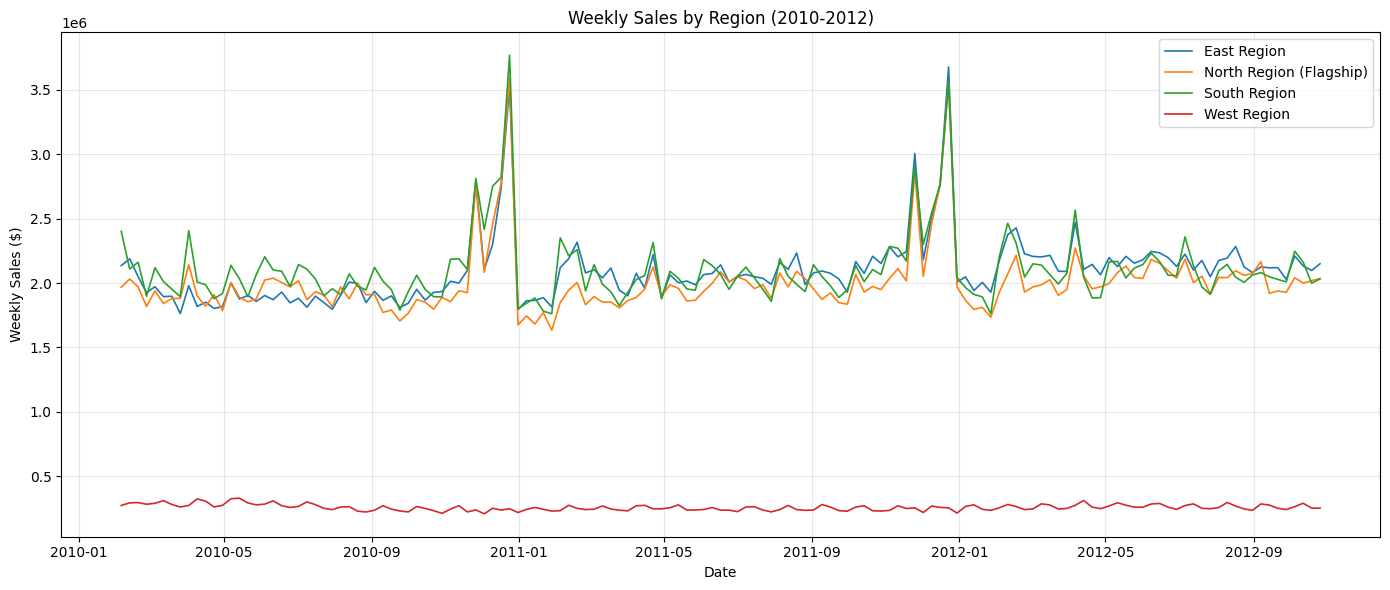

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

for region in regional_df["Region"].unique():
    region_data = regional_df[regional_df["Region"] == region]
    ax.plot(region_data["Date"], region_data["Weekly_Sales"], label=region, linewidth=1.2)

ax.set_title("Weekly Sales by Region (2010-2012)")
ax.set_xlabel("Date")
ax.set_ylabel("Weekly Sales ($)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Check for missing values in our regional dataset
print(regional_df.isnull().sum())

# Confirm each region has the same number of weeks (no gaps)
print("\nWeeks per region:")
print(regional_df.groupby("Region")["Date"].count())

# Confirm dates align across all 4 regions (same weeks, no region missing a date the others have)
print("\nUnique dates per region match total unique dates?",
      regional_df.groupby("Region")["Date"].nunique().eq(regional_df["Date"].nunique()).all())

Store           0
Date            0
IsHoliday       0
Type            0
Size            0
Weekly_Sales    0
Region          0
dtype: int64

Weeks per region:
Region
East Region                143
North Region (Flagship)    143
South Region               143
West Region                143
Name: Date, dtype: int64

Unique dates per region match total unique dates? True


In [20]:
from sklearn.preprocessing import MinMaxScaler

# We'll build one LSTM that learns from all 4 regions, so each region needs its own scaler
# (regions have very different scales - West Region is ~7x smaller than the others)
scalers = {}
scaled_data = {}

for region in regional_df["Region"].unique():
    region_data = regional_df[regional_df["Region"] == region].copy()

    # Two features: Weekly_Sales and IsHoliday (converted to 0/1)
    region_data["IsHoliday_numeric"] = region_data["IsHoliday"].astype(int)
    features = region_data[["Weekly_Sales", "IsHoliday_numeric"]].values

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(features)

    scalers[region] = scaler
    scaled_data[region] = scaled

print("Regions processed:", list(scaled_data.keys()))
print("Shape for one region:", scaled_data["East Region"].shape)

Regions processed: ['East Region', 'North Region (Flagship)', 'South Region', 'West Region']
Shape for one region: (143, 2)


In [21]:
import numpy as np

def create_sequences_multifeature(data, window_size):
    """
    data: array of shape (timesteps, n_features)
    Returns X of shape (samples, window_size, n_features) and y of shape (samples, 1)
    Note: y only predicts Weekly_Sales (column 0), not IsHoliday - we don't need to predict holidays, just sales
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size, 0])  # column 0 = Weekly_Sales only
    return np.array(X), np.array(y)

window_size = 4  # use the past 4 weeks to predict the next week

all_X = []
all_y = []

for region in scaled_data:
    X_region, y_region = create_sequences_multifeature(scaled_data[region], window_size)
    all_X.append(X_region)
    all_y.append(y_region)

# Stack all regions together into one combined training set
X_combined = np.concatenate(all_X, axis=0)
y_combined = np.concatenate(all_y, axis=0)

print("Combined X shape:", X_combined.shape)
print("Combined y shape:", y_combined.shape)

Combined X shape: (556, 4, 2)
Combined y shape: (556,)


In [22]:
train_X_list, train_y_list = [], []
test_X_list, test_y_list = [], []

for region in scaled_data:
    X_region, y_region = create_sequences_multifeature(scaled_data[region], window_size)

    split_point = int(len(X_region) * 0.8)

    train_X_list.append(X_region[:split_point])
    train_y_list.append(y_region[:split_point])
    test_X_list.append(X_region[split_point:])
    test_y_list.append(y_region[split_point:])

X_train = np.concatenate(train_X_list, axis=0)
y_train = np.concatenate(train_y_list, axis=0)
X_test = np.concatenate(test_X_list, axis=0)
y_test = np.concatenate(test_y_list, axis=0)

print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_test:", X_test.shape, " y_test:", y_test.shape)

# Convert to PyTorch tensors
import torch
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).unsqueeze(1)  # shape (n, 1) to match model output
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).unsqueeze(1)

print("\nTensor shapes - X_train:", X_train.shape, " y_train:", y_train.shape)

X_train: (444, 4, 2)  y_train: (444,)
X_test: (112, 4, 2)  y_test: (112,)

Tensor shapes - X_train: torch.Size([444, 4, 2])  y_train: torch.Size([444, 1])


In [23]:
import torch.nn as nn

class MultiRegionLSTM(nn.Module):
    def __init__(self, input_size=2, hidden_size=64, num_layers=2):
        super(MultiRegionLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, (hidden, cell) = self.lstm(x)
        last_output = lstm_out[:, -1, :]
        prediction = self.fc(last_output)
        return prediction

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiRegionLSTM(input_size=2, hidden_size=64, num_layers=2).to(device)
print(model)

MultiRegionLSTM(
  (lstm): LSTM(2, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [24]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

X_train_dev = X_train.to(device)
y_train_dev = y_train.to(device)
X_test_dev = X_test.to(device)
y_test_dev = y_test.to(device)

num_epochs = 150
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    train_outputs = model(X_train_dev)
    train_loss = criterion(train_outputs, y_train_dev)
    train_loss.backward()
    optimizer.step()
    train_losses.append(train_loss.item())

    # Check validation loss WITHOUT training on it - just evaluating
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_dev)
        val_loss = criterion(val_outputs, y_test_dev)
        val_losses.append(val_loss.item())

    if (epoch + 1) % 15 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {train_loss.item():.5f}  Val Loss: {val_loss.item():.5f}")

Epoch [15/150]  Train Loss: 0.03235  Val Loss: 0.01641
Epoch [30/150]  Train Loss: 0.02411  Val Loss: 0.00802
Epoch [45/150]  Train Loss: 0.02170  Val Loss: 0.00807
Epoch [60/150]  Train Loss: 0.01975  Val Loss: 0.00805
Epoch [75/150]  Train Loss: 0.01813  Val Loss: 0.00844
Epoch [90/150]  Train Loss: 0.01589  Val Loss: 0.00749
Epoch [105/150]  Train Loss: 0.01326  Val Loss: 0.00513
Epoch [120/150]  Train Loss: 0.01145  Val Loss: 0.00403
Epoch [135/150]  Train Loss: 0.01089  Val Loss: 0.00410
Epoch [150/150]  Train Loss: 0.01062  Val Loss: 0.00374


In [25]:
model.eval()

results_by_region = {}

with torch.no_grad():
    for region in scaled_data:
        X_region, y_region = create_sequences_multifeature(scaled_data[region], window_size)
        split_point = int(len(X_region) * 0.8)
        X_region_test = torch.FloatTensor(X_region[split_point:]).to(device)
        y_region_test = y_region[split_point:]

        preds = model(X_region_test).cpu().numpy()

        # Reverse scaling - need to reconstruct full feature shape for inverse_transform
        dummy = np.zeros((len(preds), 2))
        dummy[:, 0] = preds.flatten()
        preds_real = scalers[region].inverse_transform(dummy)[:, 0]

        dummy_actual = np.zeros((len(y_region_test), 2))
        dummy_actual[:, 0] = y_region_test
        actual_real = scalers[region].inverse_transform(dummy_actual)[:, 0]

        from sklearn.metrics import mean_absolute_percentage_error
        mape = mean_absolute_percentage_error(actual_real, preds_real)

        results_by_region[region] = {"mape": mape, "preds": preds_real, "actual": actual_real}
        print(f"{region}: MAPE = {mape*100:.2f}%")

East Region: MAPE = 3.00%
North Region (Flagship): MAPE = 3.93%
South Region: MAPE = 4.54%
West Region: MAPE = 3.36%


In [26]:
for region in scaled_data:
    actual = results_by_region[region]["actual"]
    naive_preds = actual[:-1]
    naive_actual = actual[1:]
    naive_mape = mean_absolute_percentage_error(naive_actual, naive_preds)

    print(f"{region}: LSTM MAPE = {results_by_region[region]['mape']*100:.2f}%  |  Naive MAPE = {naive_mape*100:.2f}%")

East Region: LSTM MAPE = 3.00%  |  Naive MAPE = 3.40%
North Region (Flagship): LSTM MAPE = 3.93%  |  Naive MAPE = 3.41%
South Region: LSTM MAPE = 4.54%  |  Naive MAPE = 4.47%
West Region: LSTM MAPE = 3.36%  |  Naive MAPE = 7.41%


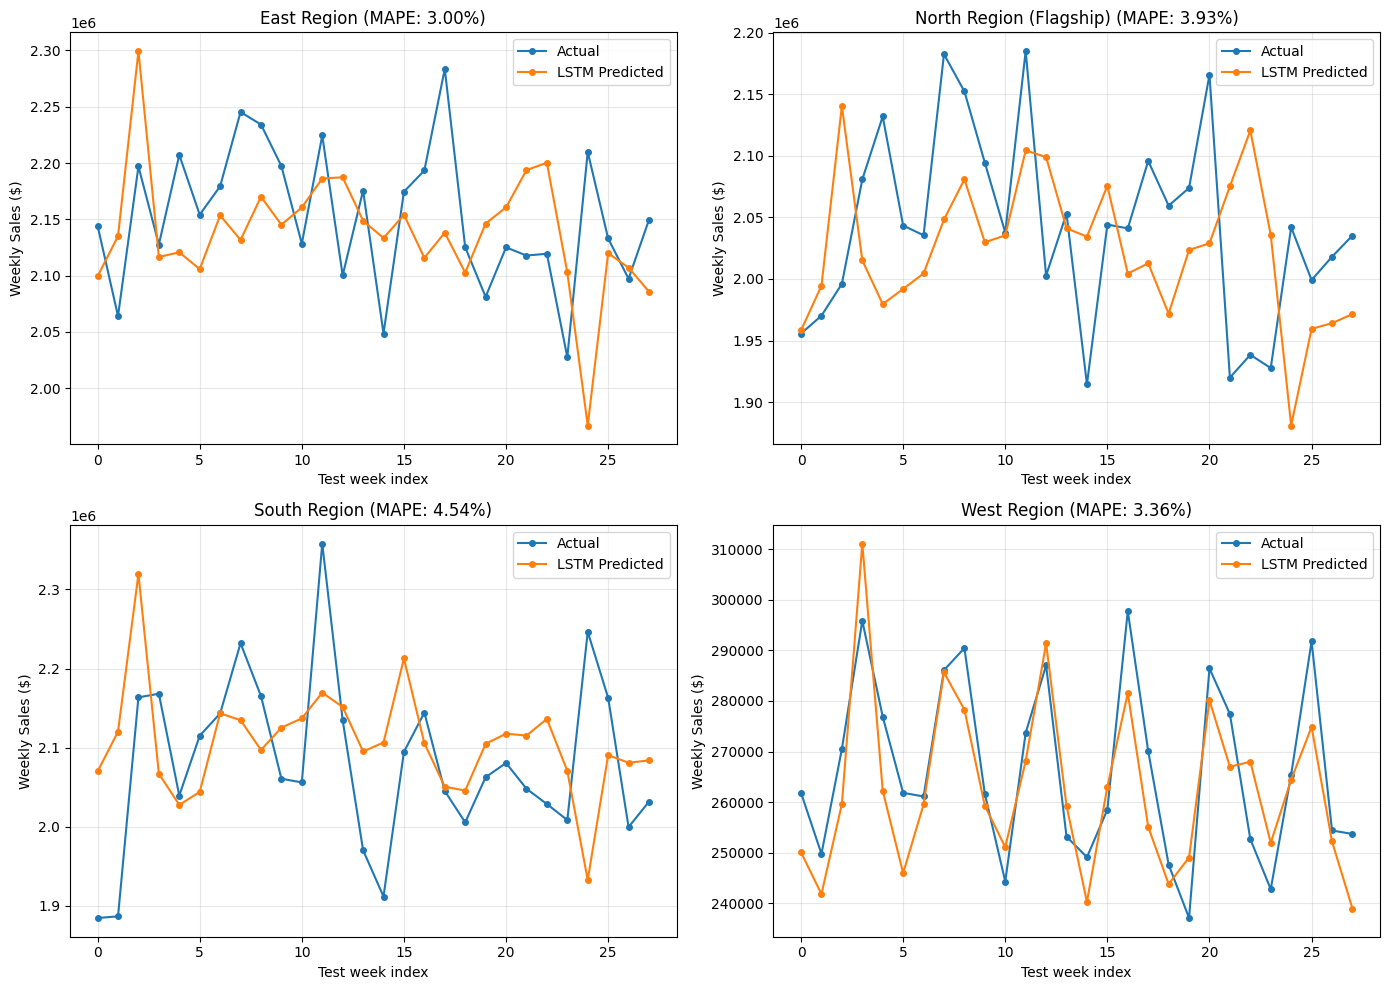

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, region in enumerate(scaled_data):
    actual = results_by_region[region]["actual"]
    preds = results_by_region[region]["preds"]

    axes[idx].plot(actual, marker="o", label="Actual", markersize=4)
    axes[idx].plot(preds, marker="o", label="LSTM Predicted", markersize=4)
    axes[idx].set_title(f"{region} (MAPE: {results_by_region[region]['mape']*100:.2f}%)")
    axes[idx].set_xlabel("Test week index")
    axes[idx].set_ylabel("Weekly Sales ($)")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
torch.save(model.state_dict(), "multi_region_lstm.pth")

import pickle
with open("region_scalers.pkl", "wb") as f:
    pickle.dump(scalers, f)

from google.colab import files
files.download("multi_region_lstm.pth")
files.download("region_scalers.pkl")

print("Model and scalers saved")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model and scalers saved


# Component 1 — Multi-Region Demand Forecasting Engine (LSTM)

Part of the Coca-Cola Demand Intelligence & Market Insights Platform. A multi-feature, multi-region LSTM that forecasts weekly demand across 4 distributor regions using real retail transaction data, holiday signals, and store characteristics.

## Objective

Forecast weekly sales demand for 4 distinct regional markets (varying in scale from a flagship metro region to a smaller satellite market), using a single shared model that learns transferable patterns — such as holiday-driven demand spikes — across all regions simultaneously.

## Dataset

- **Source:** Kaggle — "Retail Data Analytics" (`manjeetsingh/retaildataset`), a real Walmart-style multi-store retail dataset
- **3 files merged:** weekly sales by store/department (421,570 rows), store metadata (size, type), and weekly external features (temperature, fuel price, CPI, unemployment, promotional markdowns, holiday flag)
- **Regions selected:** 4 stores chosen to represent distinct "Coca-Cola regional distributors," spanning a wide range of scale — from a ~$2.0M/week flagship region to a ~$280K/week smaller satellite region — reframed for the CPG demand-forecasting narrative
- **Time span:** February 2010 to October 2012 (143 weeks), zero missing values after cleaning

## Approach

- **Architecture:** 2-layer LSTM (64 hidden units, dropout 0.2), built from scratch in PyTorch
- **Features:** 2 inputs per time step — weekly sales and a holiday flag (an upgrade from a prior single-feature forecasting model), allowing the model to receive an explicit signal for demand-spike periods rather than inferring them purely from sales history
- **Per-region scaling:** each region scaled independently (MinMaxScaler) before combining into one training set, since regions differ in scale by roughly 7x — a shared scaler would have caused the smaller region's pattern to be effectively invisible to the model
- **Training:** all 4 regions' sequences combined into one shared model (444 training / 112 test sequences) rather than 4 separate small models, to avoid data starvation while still preserving each region's own chronological train/test split
- **Validation tracked live during training:** unlike a prior single-series forecasting model, validation loss was monitored every epoch (not just at the end), confirming no overfitting occurred — both train and validation loss decreased together across 150 epochs

## Results

| Region | LSTM MAPE | Naive Baseline MAPE | Outcome |
|---|---|---|---|
| East Region | 3.00% | 3.40% | Comparable |
| North Region (Flagship) | 3.93% | 3.41% | Naive slightly better |
| South Region | 4.54% | 4.47% | Comparable |
| West Region (smaller market) | 3.36% | 7.41% | **LSTM more than halves the error** |

## Key finding — the LSTM's value is concentrated, not uniform

The LSTM did not uniformly outperform a naive "repeat last week" baseline. On the three larger, more stable regions, naive forecasting performed comparably or marginally better — these series are smooth enough that a simple persistence forecast is already a strong predictor. On the smaller, more volatile West Region, however, the LSTM provided substantial, clear value, reducing error by more than half.

**Practical implication:** rather than treating this as a uniform win or loss, the result supports a segmented forecasting strategy — applying the LSTM specifically where it demonstrably adds value (smaller, higher-volatility markets) while using simpler, cheaper methods for stable, predictable regions. This kind of model-to-segment matching is a realistic, production-relevant decision a CPG demand planning team would actually make, rather than deploying one model uniformly regardless of fit.

## What I'd improve next

- Add the unused economic features (fuel price, CPI, unemployment, promotional markdowns) as additional input channels, since only the holiday flag was used in this version
- Test a per-region fine-tuned head on top of the shared model, to combine shared-pattern learning with region-specific adaptation
- Add prediction confidence intervals, since point forecasts alone understate uncertainty for business planning

## Tech stack

`Python` · `PyTorch` · `pandas` · `scikit-learn` (MinMaxScaler) · `matplotlib` · Kaggle API · Google Colab (T4 GPU)

## How to run

1. Open `01_coca_cola_demand_forecast.ipynb` in Google Colab
2. Add your Kaggle API credentials (username + key) as environment variables
3. Run all cells in order — downloads the dataset directly from Kaggle